<a href="https://colab.research.google.com/github/tharukahashintha02/Java_02/blob/main/notebooks/01_data_preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 01 — Data Preparation & EDA
### Deployment Failure Prediction System | TravisTorrent

**Author:** Tharuka H. Dilshan — NSBM Green University

This notebook takes the raw TravisTorrent dump (3.7M job rows) and produces a clean,
leakage-free, build-level feature table split temporally into train/val/test.

**Runtime:** CPU is fine. Expect ~8-15 minutes for the full run.

**Outputs written to Drive:**
- `data/interim/builds.parquet`
- `data/processed/{train,val,test}.parquet`
- `reports/figures/*.png`


## 1. Setup

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
!pip install -q pyarrow

import os, gc, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110

# ---- EDIT THIS if your Drive layout differs -------------------------------
ROOT = '/content/drive/MyDrive/fyp-deployment-prediction'
# ---------------------------------------------------------------------------

RAW      = f'{ROOT}/data/raw/travistorrent_8_2_2017.csv.gz'
INTERIM  = f'{ROOT}/data/interim'
PROCESSED= f'{ROOT}/data/processed'
FIGURES  = f'{ROOT}/reports/figures'

for d in (INTERIM, PROCESSED, FIGURES, f'{ROOT}/models'):
    os.makedirs(d, exist_ok=True)

assert os.path.exists(RAW), f'Raw file not found at {RAW} — check the path.'
print('Raw file size: %.1f MB' % (os.path.getsize(RAW) / 1e6))

Raw file size: 192.1 MB


In [7]:
import os

base = '/content/drive/MyDrive/fyp-deployment-prediction'
print('Project folder exists:', os.path.exists(base))
print()

for sub in ['', 'data', 'data/raw', 'notebooks']:
    p = os.path.join(base, sub)
    if os.path.exists(p):
        print(f'{sub or "(root)"}/  ->  {os.listdir(p)}')
    else:
        print(f'{sub or "(root)"}/  ->  MISSING')

print()
print('--- searching all of Drive for the dataset ---')
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if 'travistorrent' in f.lower():
            print('FOUND:', os.path.join(root, f))

Project folder exists: True

(root)/  ->  ['notebooks', 'data', 'models', 'reports']
data/  ->  ['raw', 'interim', 'processed']
data/raw/  ->  ['travistorrent_8_2_2017.csv.gz']
notebooks/  ->  ['01_data_preparation.ipynb', '02_modelling_evaluation.ipynb']

--- searching all of Drive for the dataset ---
FOUND: /content/drive/MyDrive/fyp-deployment-prediction/data/raw/travistorrent_8_2_2017.csv.gz


## 2. Column selection — the leakage audit

The single most important cell in this notebook.

TravisTorrent contains many fields **derived from the build log after the build finished**.
Including any of them produces a model with near-perfect scores that is completely useless
in production, because at prediction time (before the build runs) you do not have them.

Everything in `LEAKY` below is excluded, with a reason. Reproduce this table in your
dissertation methodology chapter — it is a genuine methodological contribution.

In [8]:
# ---- Fields that LEAK the outcome (never use as features) -----------------
LEAKY = {
    'build_successful'        : 'is the label itself',
    'tr_status'               : 'is the label itself',
    'tr_log_status'           : 'parsed from the finished build log',
    'tr_log_bool_tests_failed': 'directly encodes failure',
    'tr_log_num_tests_failed' : 'directly encodes failure',
    'tr_log_tests_failed'     : 'names of the failed tests',
    'tr_log_num_tests_ok'     : 'only known after the run',
    'tr_log_num_tests_run'    : 'only known after the run',
    'tr_log_num_tests_skipped': 'only known after the run',
    'tr_log_bool_tests_ran'   : 'only known after the run',
    'tr_duration'             : 'duration is an outcome, not an input',
    'tr_log_buildduration'    : 'duration is an outcome, not an input',
    'tr_log_testduration'     : 'duration is an outcome, not an input',
    'tr_log_setup_time'       : 'only known after the run',
    'tr_log_analyzer'         : 'derived from log parsing',
    'tr_log_frameworks'       : 'derived from log parsing',
    'tr_log_lan'              : 'derived from log parsing',
    'git_merged_with'         : 'merge occurred after the build',
    'tr_virtual_merged_into'  : 'merge occurred after the build',
}

# ---- Identifiers / unusable ------------------------------------------------
DROPPED = {
    'tr_job_id'               : 'job identifier',
    'tr_jobs'                 : 'list of job ids',
    'git_all_built_commits'   : 'raw commit hash list',
    'gh_commits_in_push'      : 'raw commit hash list',
    'git_trigger_commit'      : 'commit hash',
    'tr_original_commit'      : 'commit hash',
    'git_prev_built_commit'   : 'commit hash',
    'gh_description_complexity': '85.6% missing',
    'gh_pr_created_at'        : 'redundant with build time',
    'gh_first_commit_created_at': 'high missingness, low value',
    'gh_pushed_at'            : 'high missingness',
    'gh_pull_req_num'         : 'identifier',
    'git_prev_commit_resolution_status': 'metadata about dataset construction',
}

# ---- Columns we actually read ---------------------------------------------
USECOLS = [
    # keys / label source
    'tr_build_id', 'gh_project_name', 'gh_build_started_at', 'tr_status',
    'tr_build_number', 'tr_prev_build', 'git_branch', 'gh_lang',
    # code change
    'git_diff_src_churn', 'git_diff_test_churn',
    'gh_diff_files_added', 'gh_diff_files_deleted', 'gh_diff_files_modified',
    'gh_diff_tests_added', 'gh_diff_tests_deleted',
    'gh_diff_src_files', 'gh_diff_doc_files', 'gh_diff_other_files',
    'gh_num_commits_on_files_touched', 'git_num_all_built_commits',
    'gh_num_commits_in_push',
    # project health
    'gh_sloc', 'gh_test_lines_per_kloc', 'gh_test_cases_per_kloc',
    'gh_asserts_cases_per_kloc', 'gh_team_size',
    # context
    'gh_is_pr', 'gh_by_core_team_member',
    # social (see guide - weak leakage risk, kept behind a flag)
    'gh_num_issue_comments', 'gh_num_commit_comments', 'gh_num_pr_comments',
]

print(f'{len(USECOLS)} columns read | {len(LEAKY)} excluded for leakage | '
      f'{len(DROPPED)} excluded as identifiers/unusable')

pd.DataFrame(
    [(k, v, 'LEAKAGE') for k, v in LEAKY.items()] +
    [(k, v, 'UNUSABLE') for k, v in DROPPED.items()],
    columns=['column', 'reason', 'category']
)

31 columns read | 19 excluded for leakage | 13 excluded as identifiers/unusable


,column,reason,category
0,build_successful,is the label itself,LEAKAGE
1,tr_status,is the label itself,LEAKAGE
2,tr_log_status,parsed from the finished build log,LEAKAGE
3,tr_log_bool_tests_failed,directly encodes failure,LEAKAGE
4,tr_log_num_tests_failed,directly encodes failure,LEAKAGE
5,tr_log_tests_failed,names of the failed tests,LEAKAGE
6,tr_log_num_tests_ok,only known after the run,LEAKAGE
7,tr_log_num_tests_run,only known after the run,LEAKAGE
8,tr_log_num_tests_skipped,only known after the run,LEAKAGE
9,tr_log_bool_tests_ran,only known after the run,LEAKAGE


## 3. Load and collapse jobs to builds

Each Travis build fans out into ~5.4 jobs (one per language/runtime version), and
TravisTorrent stores **one row per job**. `tr_status` is constant within a build
(verified: 0 conflicts in 85,129 sampled builds), so keeping the first row per
`tr_build_id` is safe.

We read in chunks and deduplicate as we go, which keeps peak memory well under
Colab's free-tier limit.

In [9]:
%%time
NA_VALS = ['NA', '', 'NaN', 'nan', 'null']

chunks = []
reader = pd.read_csv(
    RAW, compression='gzip', usecols=USECOLS,
    na_values=NA_VALS, keep_default_na=True,
    chunksize=400_000, low_memory=False,
)

for i, ch in enumerate(reader):
    ch = ch.drop_duplicates(subset='tr_build_id', keep='first')
    chunks.append(ch)
    print(f'  chunk {i:>2}  ->  {len(ch):>7,} unique builds')

df = pd.concat(chunks, ignore_index=True)
del chunks; gc.collect()

# builds can straddle a chunk boundary, so dedupe once more globally
df = df.drop_duplicates(subset='tr_build_id', keep='first').reset_index(drop=True)
print(f'\nBuild-level rows: {len(df):,}   (expect ~680,209)')

  chunk  0  ->   85,129 unique builds
  chunk  1  ->   86,354 unique builds
  chunk  2  ->   85,206 unique builds
  chunk  3  ->   74,364 unique builds
  chunk  4  ->   73,786 unique builds
  chunk  5  ->   66,866 unique builds
  chunk  6  ->   66,266 unique builds
  chunk  7  ->   65,120 unique builds
  chunk  8  ->   61,667 unique builds
  chunk  9  ->   15,459 unique builds

Build-level rows: 680,209   (expect ~680,209)
CPU times: user 27.5 s, sys: 4.49 s, total: 32 s
Wall time: 36.7 s


In [10]:
df.head(3)

,tr_build_id,gh_project_name,gh_is_pr,gh_lang,git_branch,gh_num_commits_in_push,tr_prev_build,gh_team_size,git_num_all_built_commits,gh_num_issue_comments,gh_num_commit_comments,gh_num_pr_comments,git_diff_src_churn,git_diff_test_churn,gh_diff_files_added,gh_diff_files_deleted,gh_diff_files_modified,gh_diff_tests_added,gh_diff_tests_deleted,gh_diff_src_files,gh_diff_doc_files,gh_diff_other_files,gh_num_commits_on_files_touched,gh_sloc,gh_test_lines_per_kloc,gh_test_cases_per_kloc,gh_asserts_cases_per_kloc,gh_by_core_team_member,gh_build_started_at,tr_status,tr_build_number
0,106060,rails/rails,False,ruby,3-1-stable,NaN,105310.0,240,5,NaN,0,NaN,18,30,0,0,7,0,0,4,0,3,3257,45012,2031.036168,180.285257,518.928286,True,2011-08-29 00:25:49,passed,499
1,106176,rails/rails,False,ruby,master,NaN,NaN,240,1,NaN,0,NaN,4,0,0,0,1,0,0,1,0,0,49,44506,2050.083135,182.829281,518.042511,True,2011-08-29 00:13:21,failed,498
2,106236,intridea/omniauth,False,ruby,master,NaN,NaN,5,1,NaN,0,NaN,3,0,0,0,1,0,0,1,0,0,5,5663,197.775031,17.835070,23.485785,True,2011-08-29 00:32:25,passed,204


## 4. Label construction

In [11]:
print('Raw status distribution:')
print(df['tr_status'].value_counts(dropna=False))

# canceled/started have no meaningful pass/fail outcome -> drop
before = len(df)
df = df[df['tr_status'].isin(['passed', 'failed', 'errored'])].copy()
print(f'\nDropped {before - len(df):,} canceled/started builds')

# failed + errored are merged: from a gating standpoint both block the pipeline.
# Justify this choice in your methodology chapter.
df['failed'] = (df['tr_status'] != 'passed').astype(np.int8)

rate = df['failed'].mean()
print(f'\nBuilds: {len(df):,}')
print(f'Failures: {df["failed"].sum():,} ({rate:.2%})')
print(f'Passes:   {(1-df["failed"]).sum():,} ({1-rate:.2%})')
print(f'\nImbalance ratio 1:{(1-rate)/rate:.2f} -- mild. '
      'Class weighting + threshold tuning should be enough; SMOTE is optional.')

Raw status distribution:
tr_status
passed      496246
failed      123149
errored      58468
canceled      2345
started          1
Name: count, dtype: int64

Dropped 2,346 canceled/started builds

Builds: 677,863
Failures: 181,617 (26.79%)
Passes:   496,246 (73.21%)

Imbalance ratio 1:2.73 -- mild. Class weighting + threshold tuning should be enough; SMOTE is optional.


## 5. Type cleaning

In [12]:
df['gh_build_started_at'] = pd.to_datetime(df['gh_build_started_at'], errors='coerce')
df = df.dropna(subset=['gh_build_started_at'])

for col in ['gh_is_pr', 'gh_by_core_team_member']:
    df[col] = (df[col].astype(str).str.upper() == 'TRUE').astype(np.int8)

NUMERIC = [
    'git_diff_src_churn', 'git_diff_test_churn',
    'gh_diff_files_added', 'gh_diff_files_deleted', 'gh_diff_files_modified',
    'gh_diff_tests_added', 'gh_diff_tests_deleted',
    'gh_diff_src_files', 'gh_diff_doc_files', 'gh_diff_other_files',
    'gh_num_commits_on_files_touched', 'git_num_all_built_commits',
    'gh_num_commits_in_push', 'gh_sloc', 'gh_test_lines_per_kloc',
    'gh_test_cases_per_kloc', 'gh_asserts_cases_per_kloc', 'gh_team_size',
    'gh_num_issue_comments', 'gh_num_commit_comments', 'gh_num_pr_comments',
]
for col in NUMERIC:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Rows after cleaning: {len(df):,}')
print(f'Date range: {df["gh_build_started_at"].min()}  ->  {df["gh_build_started_at"].max()}')

miss = (df[NUMERIC].isna().mean() * 100).sort_values(ascending=False)
print('\nMissingness (%):')
print(miss[miss > 0].round(1).to_string())

Rows after cleaning: 677,863
Date range: 2011-08-29 00:13:21  ->  2016-08-31 23:59:27

Missingness (%):
gh_num_issue_comments     84.8
gh_num_pr_comments        84.8
gh_num_commits_in_push    20.3


## 6. Feature engineering

Five feature groups, ~38 features total (your proposal promises 25+).

**Read Group 4 carefully.** Every historical feature is computed per project, in strict
time order, and passed through `.shift(1)` *before* any rolling window — so a build never
sees its own outcome. Getting this wrong silently destroys the validity of your entire
study, and you should be able to explain this cell in your viva.

In [13]:
df = df.sort_values(['gh_project_name', 'gh_build_started_at']).reset_index(drop=True)
g = df.groupby('gh_project_name', sort=False)

# ---- Group 2: derived change ratios ---------------------------------------
df['total_churn']         = df['git_diff_src_churn'].fillna(0) + df['git_diff_test_churn'].fillna(0)
df['total_files_changed'] = (df['gh_diff_files_added'].fillna(0)
                             + df['gh_diff_files_deleted'].fillna(0)
                             + df['gh_diff_files_modified'].fillna(0))
df['test_to_src_churn_ratio'] = df['git_diff_test_churn'].fillna(0) / (df['git_diff_src_churn'].fillna(0) + 1)
df['churn_per_file']          = df['total_churn'] / (df['total_files_changed'] + 1)
df['churn_relative_to_sloc']  = df['total_churn'] / (df['gh_sloc'].fillna(0) + 1)
df['is_test_only_change'] = ((df['gh_diff_src_files'].fillna(0) == 0) &
                             (df['git_diff_test_churn'].fillna(0) > 0)).astype(np.int8)
df['is_doc_only_change']  = ((df['gh_diff_src_files'].fillna(0) == 0) &
                             (df['gh_diff_doc_files'].fillna(0) > 0) &
                             (df['git_diff_test_churn'].fillna(0) == 0)).astype(np.int8)
df['tests_touched'] = ((df['gh_diff_tests_added'].fillna(0)
                        + df['gh_diff_tests_deleted'].fillna(0)) > 0).astype(np.int8)

# ---- Group 4: historical pipeline behaviour (SHIFTED — no self-leakage) ----
prev = g['failed'].shift(1)                       # lag-1 outcome
df['prev_build_failed'] = prev

for w in (5, 20):
    df[f'failure_rate_last_{w}'] = (
        g['failed'].transform(lambda s: s.shift(1).rolling(w, min_periods=1).mean())
    )

df['project_cum_failure_rate'] = g['failed'].transform(lambda s: s.shift(1).expanding().mean())
df['builds_so_far_in_project'] = g.cumcount()

# consecutive prior failures: run-length of 1s ending at the previous build
def _consec(s):
    p = s.shift(1).fillna(0).astype(int)
    grp = (p != p.shift()).cumsum()
    return p.groupby(grp).cumsum()
df['consecutive_prior_failures'] = g['failed'].transform(_consec)

# cadence
dt = g['gh_build_started_at'].diff().dt.total_seconds() / 3600.0
df['hours_since_last_build'] = dt

# df is already sorted by (project, time) and groupby sorts groups the same way,
# so the concatenated result lines up row-for-row with df.
def _builds_24h(sub):
    return sub.set_index('gh_build_started_at')['failed'].rolling('24h').count().shift(1)

df['builds_in_last_24h'] = (
    df.groupby('gh_project_name', group_keys=False, sort=True)[
        ['gh_build_started_at', 'failed']]
      .apply(_builds_24h)
      .values
)

# ---- Group 5: context / temporal ------------------------------------------
ts = df['gh_build_started_at']
df['hour_of_day'] = ts.dt.hour.astype(np.int8)
df['day_of_week'] = ts.dt.dayofweek.astype(np.int8)
df['is_weekend']  = (df['day_of_week'] >= 5).astype(np.int8)
df['month']       = ts.dt.month.astype(np.int8)
df['year']        = ts.dt.year.astype(np.int16)
df['is_default_branch'] = df['git_branch'].astype(str).str.lower().isin(
    ['master', 'main', 'develop', 'development']).astype(np.int8)
df['lang_java'] = (df['gh_lang'].astype(str).str.lower() == 'java').astype(np.int8)

# ---- Missing-value indicators + imputation --------------------------------
for col in ['gh_num_commits_in_push', 'prev_build_failed', 'hours_since_last_build']:
    df[f'{col}_was_missing'] = df[col].isna().astype(np.int8)

df['gh_num_commits_in_push'] = df['gh_num_commits_in_push'].fillna(df['git_num_all_built_commits'])
df['prev_build_failed'] = df['prev_build_failed'].fillna(0)
df['hours_since_last_build'] = df['hours_since_last_build'].fillna(
    df['hours_since_last_build'].median())
df['builds_in_last_24h'] = pd.to_numeric(df['builds_in_last_24h'], errors='coerce').fillna(0)

# The FIRST build of each project has no prior history, so the rolling/expanding
# features are NaN there (1,283 rows = one per project). Fill with 0 = "no prior
# failures observed" and flag it, so the model can learn that cold-start is a
# distinct situation rather than treating it as a genuine 0% failure rate.
df['is_first_build_in_project'] = df['failure_rate_last_5'].isna().astype(np.int8)
for col in ['failure_rate_last_5', 'failure_rate_last_20', 'project_cum_failure_rate']:
    df[col] = df[col].fillna(0)

assert df[['failure_rate_last_5', 'failure_rate_last_20', 'project_cum_failure_rate',
           'prev_build_failed', 'builds_in_last_24h', 'hours_since_last_build',
           'consecutive_prior_failures']].isna().sum().sum() == 0,     'NaNs remain in history features'
print('Feature engineering complete. No NaNs in history features.')
print(f'Columns now: {df.shape[1]}')

Feature engineering complete. No NaNs in history features.
Columns now: 59


In [14]:
FEATURES = [
    # G1 code change
    'git_diff_src_churn', 'git_diff_test_churn',
    'gh_diff_files_added', 'gh_diff_files_deleted', 'gh_diff_files_modified',
    'gh_diff_tests_added', 'gh_diff_tests_deleted',
    'gh_diff_src_files', 'gh_diff_doc_files', 'gh_diff_other_files',
    'gh_num_commits_on_files_touched', 'git_num_all_built_commits',
    'gh_num_commits_in_push',
    # G2 derived ratios
    'total_churn', 'total_files_changed', 'test_to_src_churn_ratio',
    'churn_per_file', 'churn_relative_to_sloc',
    'is_test_only_change', 'is_doc_only_change', 'tests_touched',
    # G3 project health
    'gh_sloc', 'gh_test_lines_per_kloc', 'gh_test_cases_per_kloc',
    'gh_asserts_cases_per_kloc', 'gh_team_size',
    # G4 history
    'prev_build_failed', 'failure_rate_last_5', 'failure_rate_last_20',
    'project_cum_failure_rate', 'builds_so_far_in_project',
    'consecutive_prior_failures', 'hours_since_last_build', 'builds_in_last_24h',
    # G5 context
    'gh_is_pr', 'gh_by_core_team_member', 'hour_of_day', 'day_of_week',
    'is_weekend', 'month', 'is_default_branch', 'lang_java',
    'is_first_build_in_project',
    # missing indicators
    'gh_num_commits_in_push_was_missing', 'prev_build_failed_was_missing',
    'hours_since_last_build_was_missing',
]

# Social features: weak leakage risk (counts measured at collection time, not build
# time). Default OFF. Set True to run the sensitivity analysis described in the guide.
INCLUDE_SOCIAL = False
if INCLUDE_SOCIAL:
    FEATURES += ['gh_num_issue_comments', 'gh_num_commit_comments', 'gh_num_pr_comments']

FEATURES = [f for f in FEATURES if f in df.columns]
print(f'{len(FEATURES)} features selected')

# hard guard against leakage creeping back in
leaked = [f for f in FEATURES if f in LEAKY or f in ('failed', 'tr_status')]
assert not leaked, f'LEAKAGE DETECTED: {leaked}'
print('Leakage check passed.')

46 features selected
Leakage check passed.


## 7. Save the build-level dataset

In [15]:
KEEP = ['tr_build_id', 'gh_project_name', 'gh_build_started_at',
        'tr_status', 'failed'] + FEATURES
builds = df[KEEP].copy()
builds.to_parquet(f'{INTERIM}/builds.parquet', index=False)

with open(f'{ROOT}/models/feature_names.json', 'w') as f:
    json.dump(FEATURES, f, indent=2)

print(f'Saved {len(builds):,} builds x {len(KEEP)} cols -> {INTERIM}/builds.parquet')

Saved 677,863 builds x 51 cols -> /content/drive/MyDrive/fyp-deployment-prediction/data/interim/builds.parquet


## 8. Exploratory data analysis

Each figure below belongs in your results chapter. They are saved to
`reports/figures/` automatically.

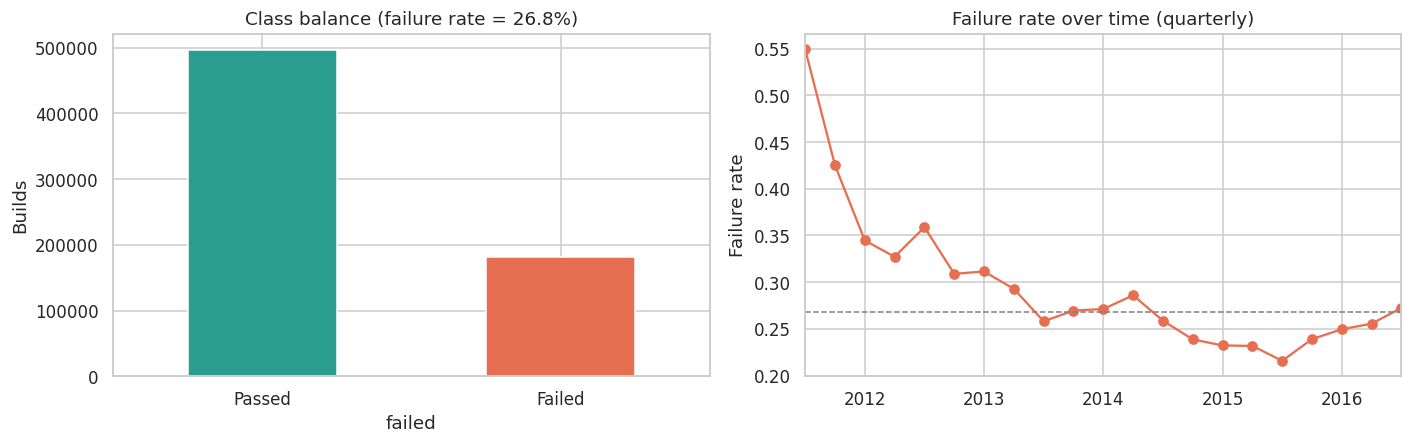

Note any drift in the right-hand plot -- it justifies a temporal split and is worth discussing as concept drift.


In [16]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

builds['failed'].value_counts().sort_index().plot(
    kind='bar', ax=ax[0], color=['#2a9d8f', '#e76f51'])
ax[0].set_xticklabels(['Passed', 'Failed'], rotation=0)
ax[0].set_title(f'Class balance (failure rate = {builds["failed"].mean():.1%})')
ax[0].set_ylabel('Builds')

monthly = (builds.set_index('gh_build_started_at')['failed']
                 .resample('QE').agg(['mean', 'count']))
monthly['mean'].plot(ax=ax[1], marker='o', color='#e76f51')
ax[1].set_title('Failure rate over time (quarterly)')
ax[1].set_ylabel('Failure rate'); ax[1].set_xlabel('')
ax[1].axhline(builds['failed'].mean(), ls='--', c='grey', lw=1)

plt.tight_layout(); plt.savefig(f'{FIGURES}/01_class_balance.png', bbox_inches='tight')
plt.show()
print('Note any drift in the right-hand plot -- it justifies a temporal split '
      'and is worth discussing as concept drift.')

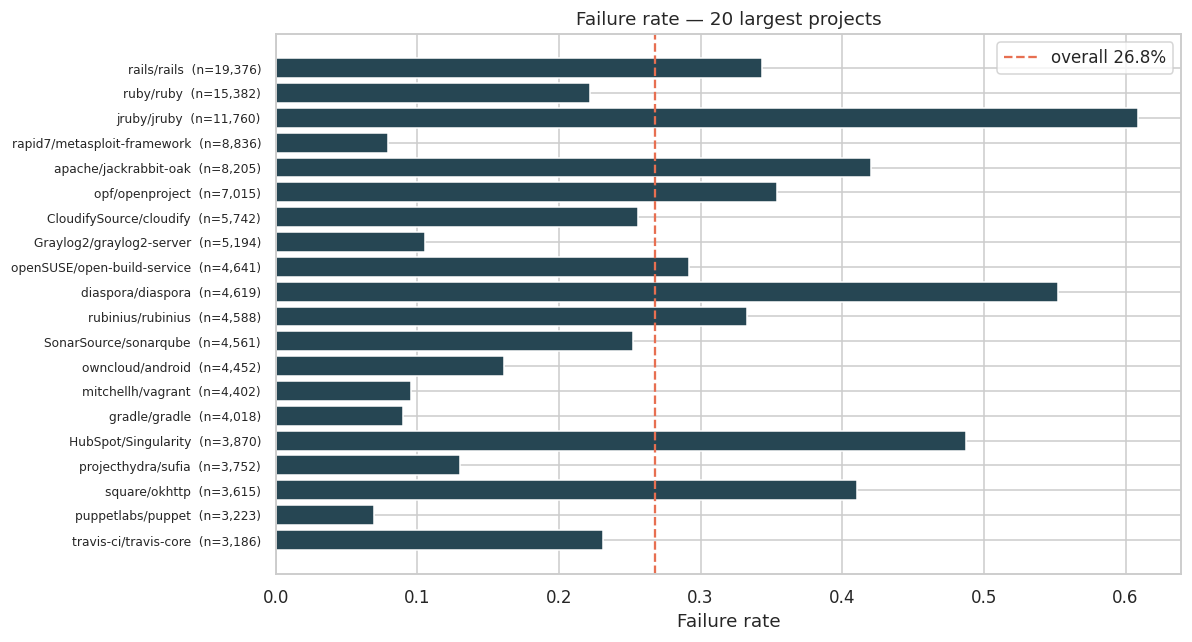

Top 2 projects = 5.1% of all builds. This is why you also need a project-grouped split (Scheme B).


In [17]:
top = builds['gh_project_name'].value_counts().head(20)
pr = builds[builds['gh_project_name'].isin(top.index)] \
        .groupby('gh_project_name')['failed'].agg(['mean', 'count']) \
        .sort_values('count', ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(range(len(pr)), pr['mean'], color='#264653')
ax.set_yticks(range(len(pr)))
ax.set_yticklabels([f'{n}  (n={c:,})' for n, c in zip(pr.index, pr['count'])], fontsize=8)
ax.invert_yaxis()
ax.axvline(builds['failed'].mean(), ls='--', c='#e76f51',
           label=f'overall {builds["failed"].mean():.1%}')
ax.set_xlabel('Failure rate'); ax.set_title('Failure rate — 20 largest projects')
ax.legend()
plt.tight_layout(); plt.savefig(f'{FIGURES}/02_by_project.png', bbox_inches='tight')
plt.show()

share = top.head(2).sum() / len(builds)
print(f'Top 2 projects = {share:.1%} of all builds. '
      'This is why you also need a project-grouped split (Scheme B).')

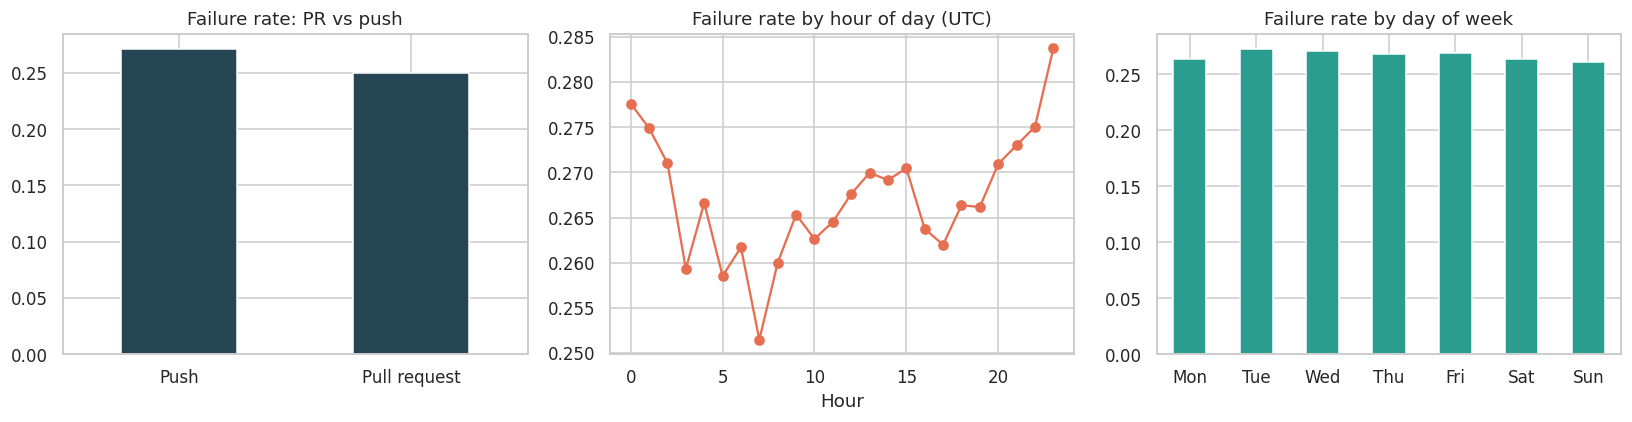

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

builds.groupby('gh_is_pr')['failed'].mean().plot(
    kind='bar', ax=ax[0], color='#264653')
ax[0].set_xticklabels(['Push', 'Pull request'], rotation=0)
ax[0].set_title('Failure rate: PR vs push'); ax[0].set_xlabel('')

builds.groupby('hour_of_day')['failed'].mean().plot(ax=ax[1], marker='o', color='#e76f51')
ax[1].set_title('Failure rate by hour of day (UTC)'); ax[1].set_xlabel('Hour')

builds.groupby('day_of_week')['failed'].mean().plot(
    kind='bar', ax=ax[2], color='#2a9d8f')
ax[2].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=0)
ax[2].set_title('Failure rate by day of week'); ax[2].set_xlabel('')

plt.tight_layout(); plt.savefig(f'{FIGURES}/03_context.png', bbox_inches='tight')
plt.show()

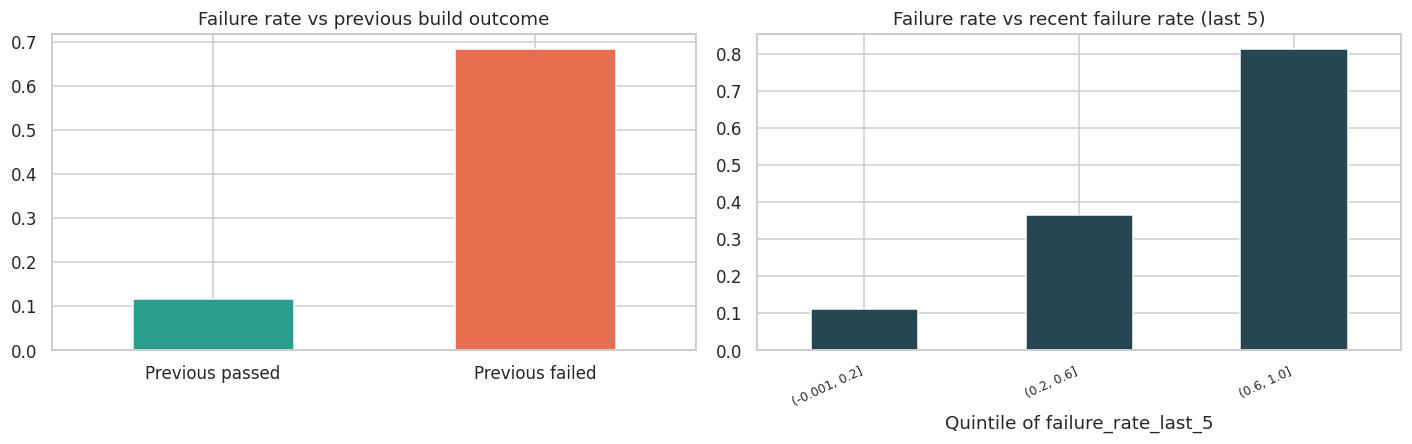

If these two plots show a strong gradient, your Group 4 history features are doing the heavy lifting -- expect SHAP to confirm it.


In [19]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

builds.groupby('prev_build_failed')['failed'].mean().plot(
    kind='bar', ax=ax[0], color=['#2a9d8f', '#e76f51'])
ax[0].set_xticklabels(['Previous passed', 'Previous failed'], rotation=0)
ax[0].set_title('Failure rate vs previous build outcome'); ax[0].set_xlabel('')

bins = pd.qcut(builds['failure_rate_last_5'], 5, duplicates='drop')
builds.groupby(bins, observed=True)['failed'].mean().plot(
    kind='bar', ax=ax[1], color='#264653')
ax[1].set_title('Failure rate vs recent failure rate (last 5)')
ax[1].set_xlabel('Quintile of failure_rate_last_5')
plt.setp(ax[1].get_xticklabels(), rotation=25, ha='right', fontsize=8)

plt.tight_layout(); plt.savefig(f'{FIGURES}/04_history_signal.png', bbox_inches='tight')
plt.show()
print('If these two plots show a strong gradient, your Group 4 history features '
      'are doing the heavy lifting -- expect SHAP to confirm it.')

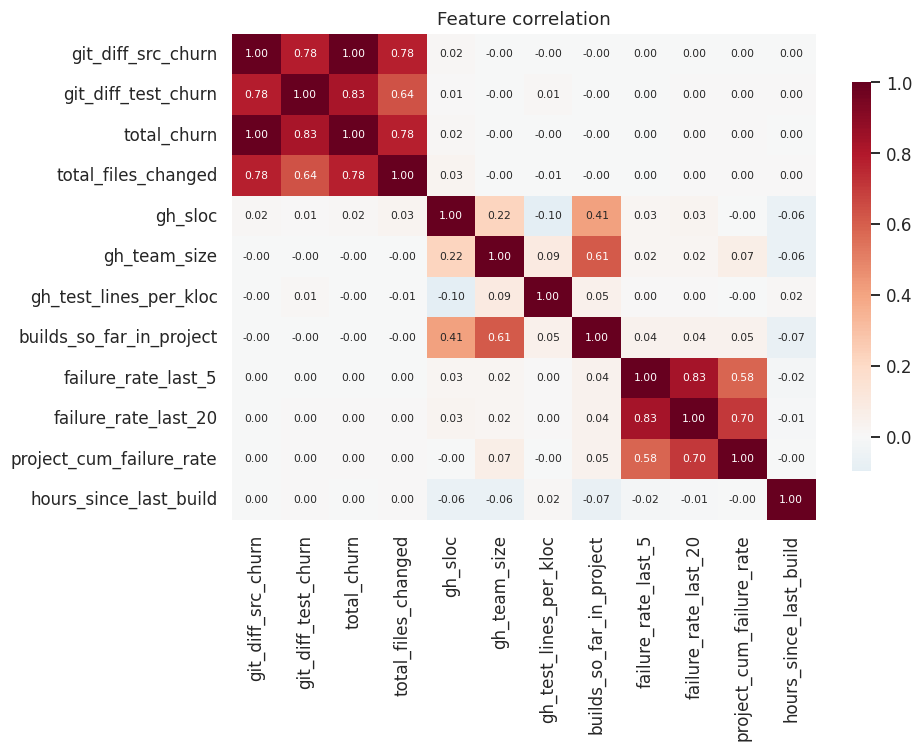

Highly collinear pairs are fine for trees; prune them for Logistic Regression.


In [20]:
num = ['git_diff_src_churn', 'git_diff_test_churn', 'total_churn',
       'total_files_changed', 'gh_sloc', 'gh_team_size',
       'gh_test_lines_per_kloc', 'builds_so_far_in_project',
       'failure_rate_last_5', 'failure_rate_last_20',
       'project_cum_failure_rate', 'hours_since_last_build']

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(builds[num].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, annot_kws={'size': 7}, cbar_kws={'shrink': .8})
ax.set_title('Feature correlation')
plt.tight_layout(); plt.savefig(f'{FIGURES}/05_correlation.png', bbox_inches='tight')
plt.show()
print('Highly collinear pairs are fine for trees; prune them for Logistic Regression.')

## 9. Train / validation / test split

**Scheme A — temporal (primary).** Sort by time, split 70/15/15. Train on the past,
test on the future. This is the honest simulation of live deployment gating and it is
what your proposal §4.4 specifies.

Scheme B (grouped by project) is built in Notebook 02, where it is used to test
cross-project generalisation.

In [21]:
builds = builds.sort_values('gh_build_started_at').reset_index(drop=True)
n = len(builds)
i_tr, i_va = int(n * 0.70), int(n * 0.85)

train = builds.iloc[:i_tr].copy()
val   = builds.iloc[i_tr:i_va].copy()
test  = builds.iloc[i_va:].copy()

for name, d in [('TRAIN', train), ('VAL', val), ('TEST', test)]:
    print(f'{name:<6} {len(d):>7,} builds | '
          f'{d["gh_build_started_at"].min().date()} -> {d["gh_build_started_at"].max().date()} | '
          f'failure rate {d["failed"].mean():.2%}')

# sanity: no temporal overlap
assert train['gh_build_started_at'].max() <= val['gh_build_started_at'].min()
assert val['gh_build_started_at'].max()   <= test['gh_build_started_at'].min()
print('\nTemporal ordering verified — no look-ahead leakage.')

train.to_parquet(f'{PROCESSED}/train.parquet', index=False)
val.to_parquet(f'{PROCESSED}/val.parquet', index=False)
test.to_parquet(f'{PROCESSED}/test.parquet', index=False)
print(f'Saved to {PROCESSED}/')

TRAIN  474,504 builds | 2011-08-29 -> 2015-04-23 | failure rate 27.90%
VAL    101,679 builds | 2015-04-23 -> 2015-12-11 | failure rate 22.33%
TEST   101,680 builds | 2015-12-11 -> 2016-08-31 | failure rate 26.09%

Temporal ordering verified — no look-ahead leakage.
Saved to /content/drive/MyDrive/fyp-deployment-prediction/data/processed/


### Note the failure rates across splits

If the test-set failure rate differs noticeably from the training set, you have
**concept drift** — the CI ecosystem changed between 2011 and 2016. Do not treat this
as a bug. Discuss it in your results chapter; it motivates periodic retraining, which
is exactly the drift-monitoring point your proposal makes in §4.5.3.

---

## Done — next: Notebook 02 (Modelling & Evaluation)

**Checklist before moving on:**
- [ ] `builds.parquet` and the three split files exist in Drive
- [ ] Failure rate is in the 25–40% range (not ~0% or ~100% — that would signal a label bug)
- [ ] Leakage assertion passed
- [ ] All five figures saved to `reports/figures/`
- [ ] You can explain the `.shift(1)` logic in Section 6 in your own words
